# DIGITAL TRANSACTION RISK ANALYSIS
## Unit VI: Time-Series Analysis and Forecasting

This final unit analyzes the temporal patterns of transaction data. We investigate trends, seasonality, and autocorrelation, apply smoothing techniques, and build an ARIMA model to forecast future transaction behavior.

In [1]:
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 4.1 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.6 MB 3.5 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.6 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.6 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.6 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.6 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.6 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 2.6 MB/s eta 0:00:02
   --------------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading dataset...
Time series span: 2019-01-01 to 2020-06-21
Frequency      : Daily ('D')
Length         : 538 days
Missing days   : 0


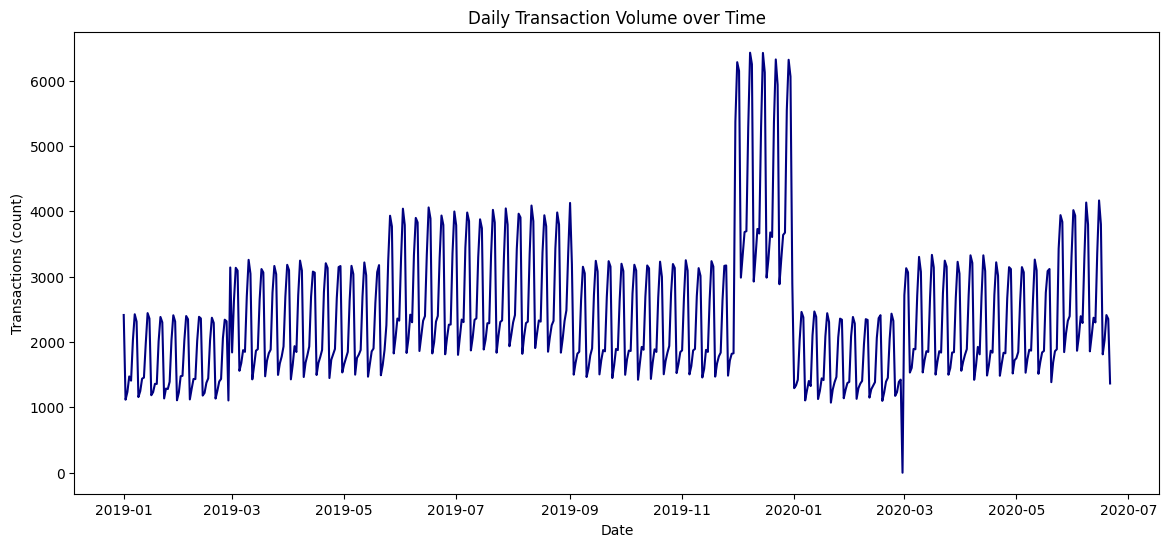

In [1]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA AGGREGATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from itertools import product
import warnings

warnings.filterwarnings("ignore")

print("Loading dataset...")
df = pd.read_csv('fraudTrain.csv')

# Convert to datetime and aggregate transaction VOLUME by day (count of transactions)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

ts_daily = (
    df.set_index('trans_date_trans_time')
      .sort_index()
      .resample('D')
      .size()
      .asfreq('D', fill_value=0)
      .rename('tx_count')
)

# Checklist item 1: frequency + span + gap check
expected_index = pd.date_range(ts_daily.index.min(), ts_daily.index.max(), freq='D')
missing_days = expected_index.difference(ts_daily.index)

print(f"Time series span: {ts_daily.index.min().date()} to {ts_daily.index.max().date()}")
print(f"Frequency      : Daily ('D')")
print(f"Length         : {len(ts_daily):,} days")
print(f"Missing days   : {len(missing_days)}")

plt.figure(figsize=(14, 6))
plt.plot(ts_daily, color='navy')
plt.title('Daily Transaction Volume over Time')
plt.xlabel('Date')
plt.ylabel('Transactions (count)')
plt.show()


## 0.5 Visual Inspection (Mandatory narrative)
After plotting the raw daily series above:
- **Trend:** Comment on whether the overall level drifts upward/downward over time.
- **Seasonality:** Look for repeating weekly cycles (common in transaction data).
- **Noise / irregularity:** Note spikes, dips, and variability.

**Short description (edit if needed):** The daily transaction volume shows a stable overall level with recurring weekly seasonality and irregular fluctuations/spikes typical of day-to-day behavior.

## 1. Trend and Seasonality Decomposition
**Objective:** Break the time series into its constituent components: Trend, Seasonality, and Residuals.


TIME SERIES DECOMPOSITION


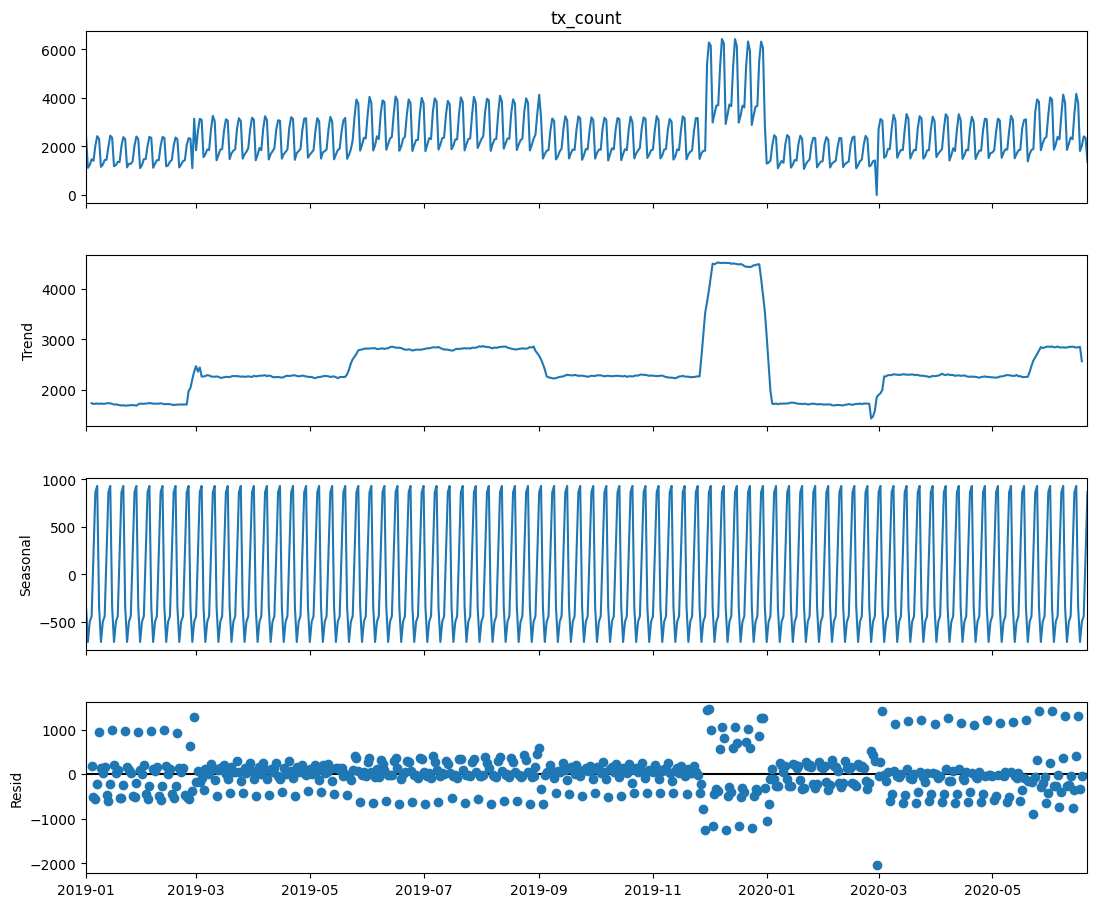

Interpretation: The plots show a clear weekly seasonality in transaction habits.


In [2]:
print('\n' + '='*60)
print('TIME SERIES DECOMPOSITION')
print('='*60)

decomposition = seasonal_decompose(ts_daily.dropna(), model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

print("Interpretation: The plots show a clear weekly seasonality in transaction habits.")


## 2. Smoothing Techniques: Moving Average & Exponential Smoothing
**Objective:** Filter noise using Moving Average and predict the next value using Exponential Smoothing.


SMOOTHING TECHNIQUES


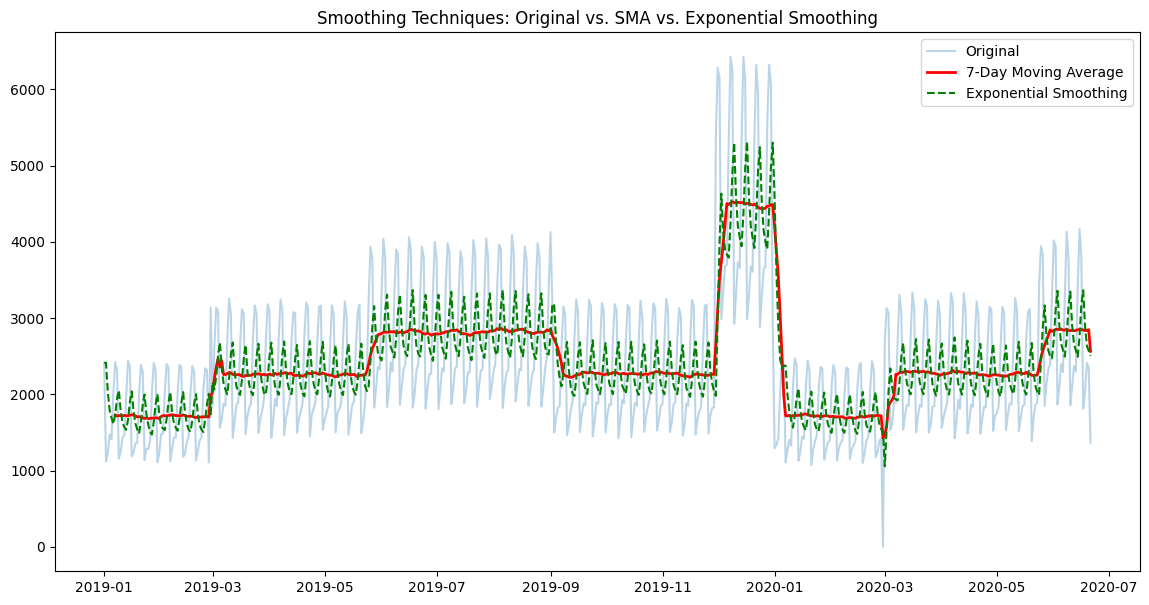

In [3]:
print('\n' + '='*60)
print('SMOOTHING TECHNIQUES')
print('='*60)

# Simple Moving Average (7-day window)
sma_7 = ts_daily.rolling(window=7).mean()

# Exponential Smoothing
model_es = SimpleExpSmoothing(ts_daily.dropna()).fit(smoothing_level=0.3, optimized=False)
es_forecast = model_es.fittedvalues

plt.figure(figsize=(14, 7))
plt.plot(ts_daily, label='Original', alpha=0.3)
plt.plot(sma_7, label='7-Day Moving Average', color='red', lw=2)
plt.plot(es_forecast, label='Exponential Smoothing', color='green', linestyle='--')
plt.title('Smoothing Techniques: Original vs. SMA vs. Exponential Smoothing')
plt.legend()
plt.show()


## 2.5 Stationarity Testing (ADF) + Differencing (Mandatory)
**Objective:** Run the Augmented Dickey-Fuller (ADF) test and formally justify the differencing order $d$.
- Report: ADF statistic, p-value, and critical values (1\%, 5\%, 10\%).
- If $p > 0.05$, apply first differencing and retest until stationary.

This section produces `stationary_series` and `d_order` for later ACF/PACF and ARIMA fitting.

In [4]:
print("\n" + "=" * 60)
print("STATIONARITY TESTING (ADF) + DIFFERENCING")
print("=" * 60)

def adf_report(series: pd.Series, name: str) -> dict:
    series = series.dropna()
    res = adfuller(series, autolag="AIC")
    adf_stat = res[0]
    pval = res[1]
    used_lag = res[2]
    nobs = res[3]
    crit = res[4]
    print(f"\n{name}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {pval:.4e}")
    print(f"Used lag      : {used_lag}")
    print(f"N obs         : {nobs}")
    print("Critical values:")
    for k, v in crit.items():
        print(f"  {k:>4}: {v:.4f}")
    return {"adf": adf_stat, "p": pval, "crit": crit}

series_raw = ts_daily.astype(float)
d_order = 0
adf_history = []

report = adf_report(series_raw, "Raw series (daily transaction count)")
adf_history.append({"d": d_order, **report})

stationary_series = series_raw.copy()
while report["p"] > 0.05 and d_order < 3:
    d_order += 1
    stationary_series = stationary_series.diff()
    report = adf_report(stationary_series, f"After differencing d = {d_order}")
    adf_history.append({"d": d_order, **report})

if report["p"] <= 0.05:
    print(f"\nConclusion: Stationarity achieved at d = {d_order} (p <= 0.05).")
else:
    print(f"\nConclusion: Still non-stationary after d = {d_order}. Consider seasonal differencing or transformation.")

print("=" * 60)


STATIONARITY TESTING (ADF) + DIFFERENCING

Raw series (daily transaction count)
ADF Statistic : -3.4895
p-value       : 8.2602e-03
Used lag      : 14
N obs         : 523
Critical values:
    1%: -3.4429
    5%: -2.8671
   10%: -2.5697

Conclusion: Stationarity achieved at d = 0 (p <= 0.05).


## 3. Autocorrelation (ACF) and PACF
**Objective:** Determine the correlation of the series with its own past values to identify AR and MA components.


ACF / PACF (ON STATIONARY SERIES)


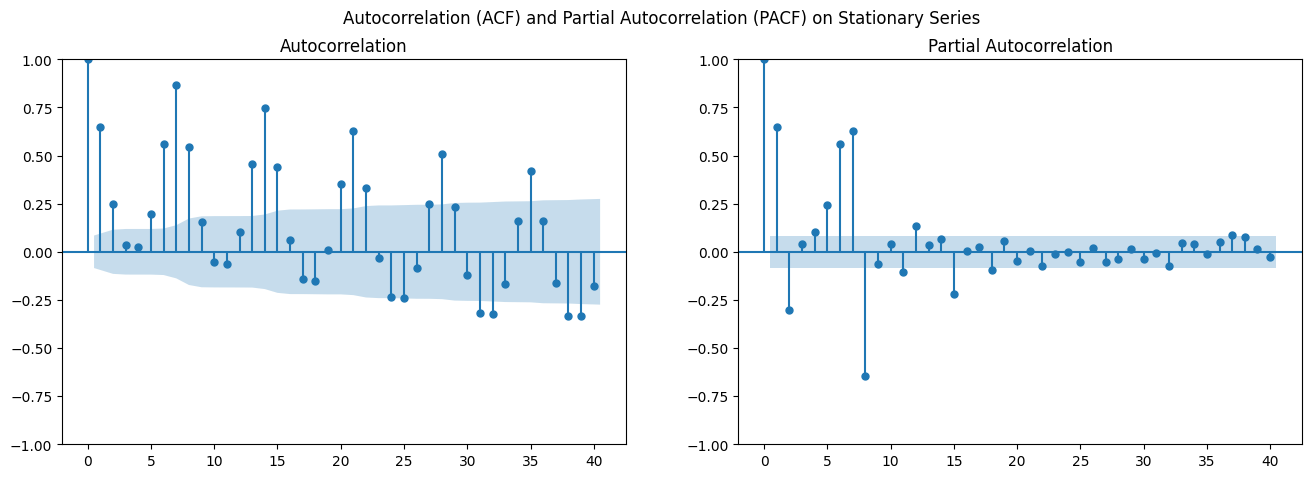

In [5]:
print("\n" + "=" * 60)
print("ACF / PACF (ON STATIONARY SERIES)")
print("=" * 60)

# Mandatory: ACF/PACF must be plotted on the stationary series
series_stationary = stationary_series.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(series_stationary, lags=40, ax=ax1)
plot_pacf(series_stationary, lags=40, ax=ax2, method="ywm")
plt.suptitle('Autocorrelation (ACF) and Partial Autocorrelation (PACF) on Stationary Series')
plt.show()

## 3.5 Model Selection (AIC/BIC Table)
**Objective:** Fit multiple ARIMA$(p,d,q)$ candidates and compare their AIC/BIC.
- Try at least two parameter sets (more is fine).
- Select the model with the lowest AIC (and check BIC consistency).
- Keep $d$ equal to the differencing order found by the ADF test above.

In [6]:
print("\n" + "=" * 60)
print("MODEL SELECTION: ARIMA CANDIDATES (AIC/BIC)")
print("=" * 60)

# Use the original (undifferenced) series; ARIMA will apply differencing via d_order
series_for_arima = ts_daily.astype(float)

candidate_orders = []
for p, q in product([0, 1, 2, 3], [0, 1, 2, 3]):
    if p == 0 and q == 0:
        continue
    candidate_orders.append((p, d_order, q))

rows = []
for order in candidate_orders:
    try:
        res = ARIMA(series_for_arima, order=order).fit()
        rows.append({"order": order, "aic": res.aic, "bic": res.bic})
    except Exception:
        continue

model_table = (
    pd.DataFrame(rows)
    .sort_values("aic")
    .reset_index(drop=True)
 )

print("Top candidate models (lowest AIC):")
print(model_table.head(10).to_string(index=False))

selected_order = tuple(model_table.loc[0, "order"])
print(f"\nSelected ARIMA order (lowest AIC): {selected_order}")
print("=" * 60)


MODEL SELECTION: ARIMA CANDIDATES (AIC/BIC)
Top candidate models (lowest AIC):
    order         aic         bic
(3, 0, 3) 8341.254821 8375.557690
(3, 0, 2) 8513.560445 8543.575455
(2, 0, 3) 8520.638802 8550.653812
(2, 0, 2) 8530.214620 8555.941771
(1, 0, 2) 8531.808742 8553.248034
(1, 0, 3) 8545.865212 8571.592364
(0, 0, 2) 8549.448667 8566.600101
(0, 0, 3) 8594.228556 8615.667848
(2, 0, 0) 8611.153967 8628.305401
(3, 0, 0) 8612.222145 8633.661438

Selected ARIMA order (lowest AIC): (3, 0, 3)


## 4. ARIMA Modeling and Forecasting
**Objective:** Build a predictive model and forecast the transaction volume for the next 30 days.


ARIMA MODELING, DIAGNOSTICS, FORECASTING, AND EVALUATION
Train span: 2019-01-01 to 2020-05-22 (508 days)
Test  span: 2020-05-23 to 2020-06-21 (30 days)

Fitting ARIMA(3, 0, 3) ...
                               SARIMAX Results                                
Dep. Variable:               tx_count   No. Observations:                  508
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -3929.367
Date:                Tue, 05 May 2026   AIC                           7874.734
Time:                        11:57:50   BIC                           7908.578
Sample:                    01-01-2019   HQIC                          7888.005
                         - 05-22-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2389.4180    113.

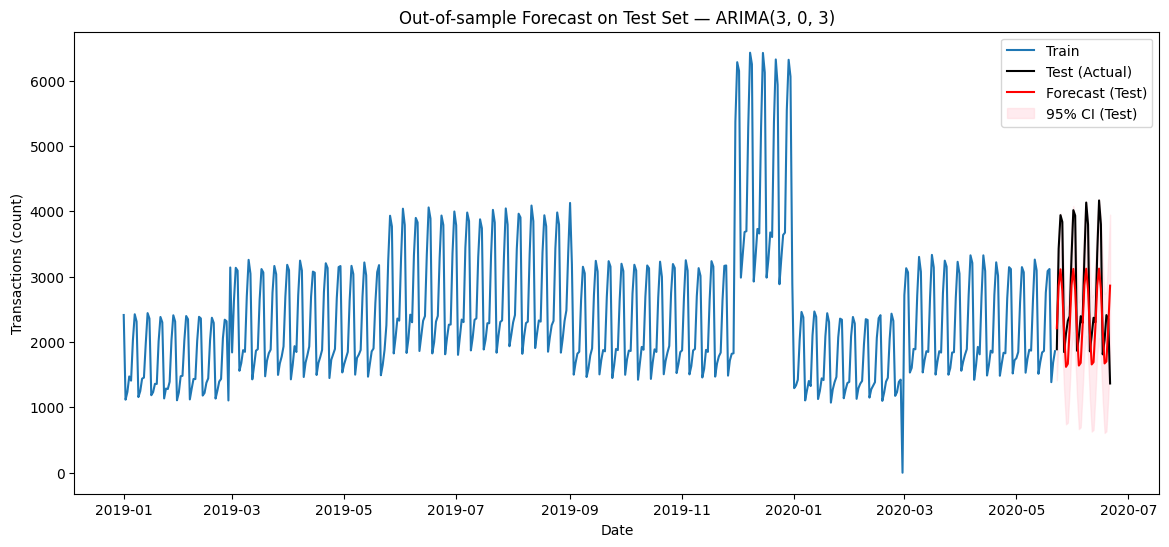

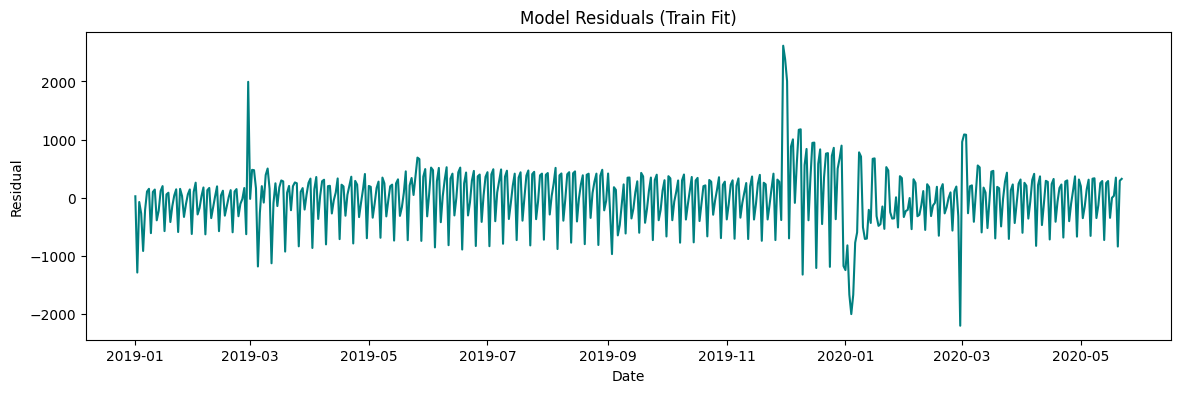


Ljung-Box test (H0: no autocorrelation in residuals):
        lb_stat      lb_pvalue
10   426.722121   1.918219e-85
20   852.264235  1.118295e-167
30  1350.398109  2.789327e-265
Conclusion: Some p-values <= 0.05 → residual autocorrelation remains (model may be misspecified).


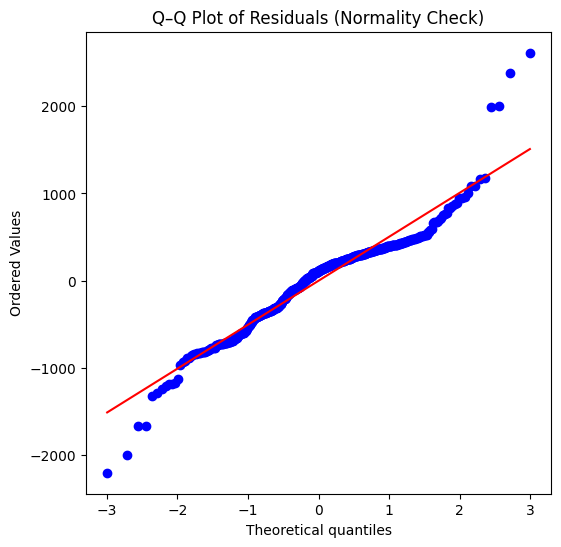

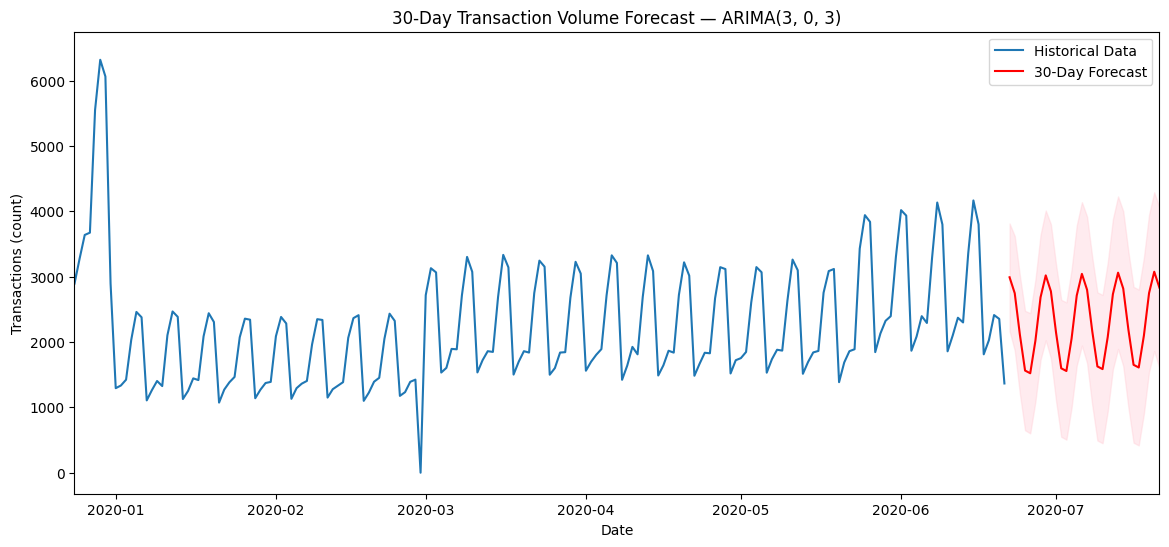

UNIT VI COMPLETE: PROJECT COMPLETED


In [7]:
print("\n" + "=" * 60)
print("ARIMA MODELING, DIAGNOSTICS, FORECASTING, AND EVALUATION")
print("=" * 60)

series = ts_daily.astype(float)

# -------------------------------
# Train/Test split (out-of-sample)
# -------------------------------
test_horizon = 30  # 7–30 steps ahead (requirement)
train = series.iloc[:-test_horizon]
test = series.iloc[-test_horizon:]

print(f"Train span: {train.index.min().date()} to {train.index.max().date()} ({len(train):,} days)")
print(f"Test  span: {test.index.min().date()} to {test.index.max().date()} ({len(test):,} days)")

# -------------------------------
# Fit selected ARIMA(p,d,q)
# -------------------------------
order = selected_order if "selected_order" in globals() else (1, d_order, 1)
print(f"\nFitting ARIMA{order} ...")
results = ARIMA(train, order=order).fit()
print(results.summary())

# -------------------------------
# Forecast on test set + metrics
# -------------------------------
fc_test = results.get_forecast(steps=test_horizon)
pred_test = pd.Series(fc_test.predicted_mean.to_numpy(), index=test.index)
ci_test = fc_test.conf_int()
ci_test.index = test.index

rmse = float(np.sqrt(np.mean((test - pred_test) ** 2)))
mae = float(np.mean(np.abs(test - pred_test)))
mape = float(np.mean(np.abs((test - pred_test) / test.replace(0, np.nan))) * 100)

print("\nEvaluation on test set:")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"MAPE: {mape:.3f}% (ignores days with 0 actual)")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test (Actual)", color="black")
plt.plot(pred_test.index, pred_test, label="Forecast (Test)", color="red")
plt.fill_between(
    ci_test.index,
    ci_test.iloc[:, 0].to_numpy(),
    ci_test.iloc[:, 1].to_numpy(),
    color="pink",
    alpha=0.3,
    label="95% CI (Test)",
)
plt.title(f"Out-of-sample Forecast on Test Set — ARIMA{order}")
plt.xlabel("Date")
plt.ylabel("Transactions (count)")
plt.legend()
plt.show()

# -------------------------------
# Residual diagnostics (Mandatory)
# -------------------------------
resid = results.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(resid, color="teal")
plt.title("Model Residuals (Train Fit)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation in residuals):")
print(lb.to_string())
if (lb['lb_pvalue'] > 0.05).all():
    print("Conclusion: p-values > 0.05 → residuals look like white noise (good).")
else:
    print("Conclusion: Some p-values <= 0.05 → residual autocorrelation remains (model may be misspecified).")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
stats.probplot(resid, dist="norm", plot=ax)
ax.set_title("Q–Q Plot of Residuals (Normality Check)")
plt.show()

# -------------------------------
# Refit on full series, forecast future 30 days
# -------------------------------
results_full = ARIMA(series, order=order).fit()
forecast_steps = 30
fc_future = results_full.get_forecast(steps=forecast_steps)
future_ci = fc_future.conf_int()

future_index = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq='D',
)
future_mean = pd.Series(fc_future.predicted_mean.to_numpy(), index=future_index)
future_ci.index = future_index

plt.figure(figsize=(14, 6))
plt.plot(series, label="Historical Data")
plt.plot(future_mean, color="red", label="30-Day Forecast")
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0].to_numpy(),
    future_ci.iloc[:, 1].to_numpy(),
    color="pink",
    alpha=0.3,
)
plt.xlim(series.index.max() - pd.Timedelta(days=180), future_index.max())
plt.title(f"30-Day Transaction Volume Forecast — ARIMA{order}")
plt.xlabel("Date")
plt.ylabel("Transactions (count)")
plt.legend()
plt.show()

print("=" * 60)
print("UNIT VI COMPLETE: PROJECT COMPLETED")
print("=" * 60)